In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns

sns.set_theme()

In [15]:
data = loadmat('cluster_dataset.mat')

In [16]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

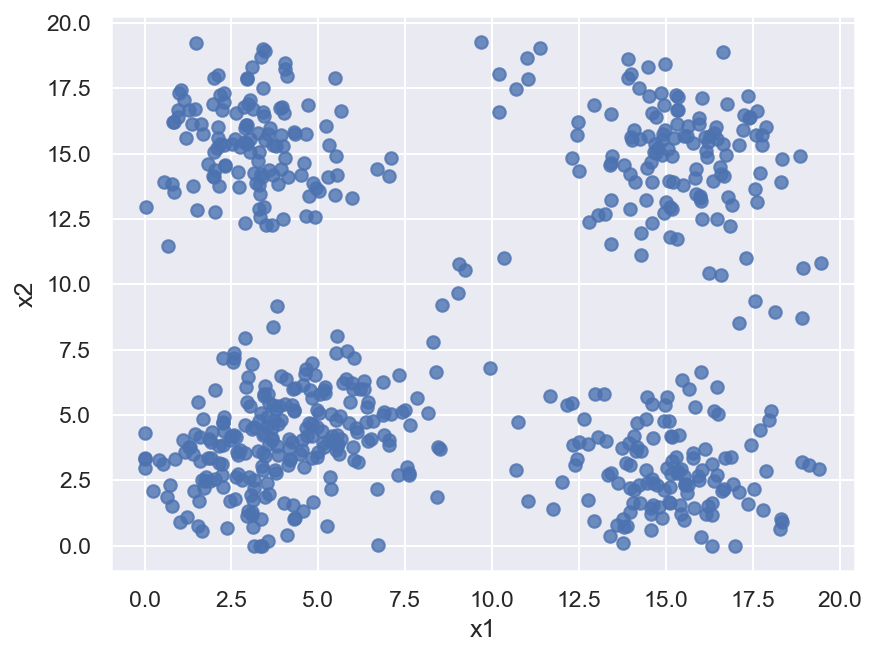

In [17]:
plt.figure(dpi=150)
plt.scatter(x1, x2, color='b', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [7]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [6]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    if k <= 0:
        raise ValueError("k must be positive")
    if k > len(X):
        raise ValueError("k must be <= number of samples")
    indices = random.sample(range(len(X)), k)
    centers = [np.array(X[i], dtype=float) for i in indices]
    return centers

In [13]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    return np.linalg.norm(v1 - v2)

In [9]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    assignment = {i: [] for i in range(len(centers))}
    for x in X:
        distances = [distance(x, c) for c in centers]
        cluster_idx = int(np.argmin(distances))
        assignment[cluster_idx].append(np.array(x))
    return assignment

In [14]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    total = 0.0
    count = 0
    for idx, points in assignment.items():
        if len(points) == 0:
            continue
        center = centers[idx]
        for p in points:
            total += distance(p, center)
        count += len(points)
    cost = total / count if count > 0 else 0.0
    return cost

In [15]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    new_centers = []
    for idx in range(len(centers)):
        points = assignment[idx]
        if len(points) == 0:
            new_centers.append(centers[idx])
        else:
            new_centers.append(np.mean(np.array(points), axis=0))
    stop = 1 if all(np.allclose(centers[i], new_centers[i]) for i in range(len(centers))) else 0
    return new_centers, stop

In [16]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:, 0]
        x2 = cluster[:, 1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker='*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch' + str(epoch))
    plt.show()

In [17]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    centers = init_centers(X, k)
    assignment = None
    cost = None
    for epoch in range(max_epoch):
        assignment = cluster_assignment(X, centers)
        cost = cost_function(assignment, centers)
        if plot:
            plot_clustering(assignment, centers, epoch)
        centers, stop = center_update(assignment, centers)
        if stop == 1:
            break
    return assignment, cost

In [18]:
max_epoch = 200

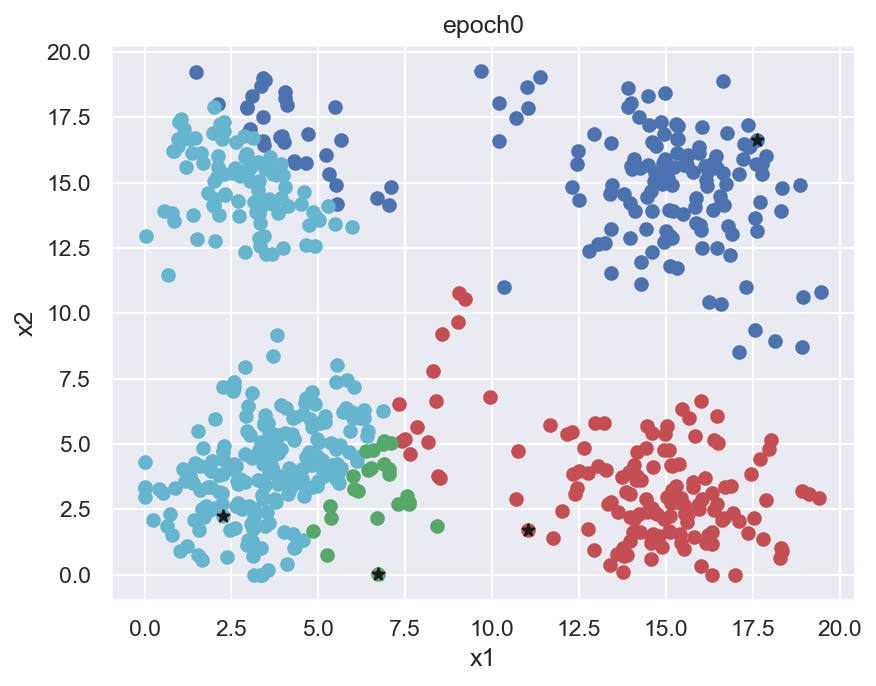

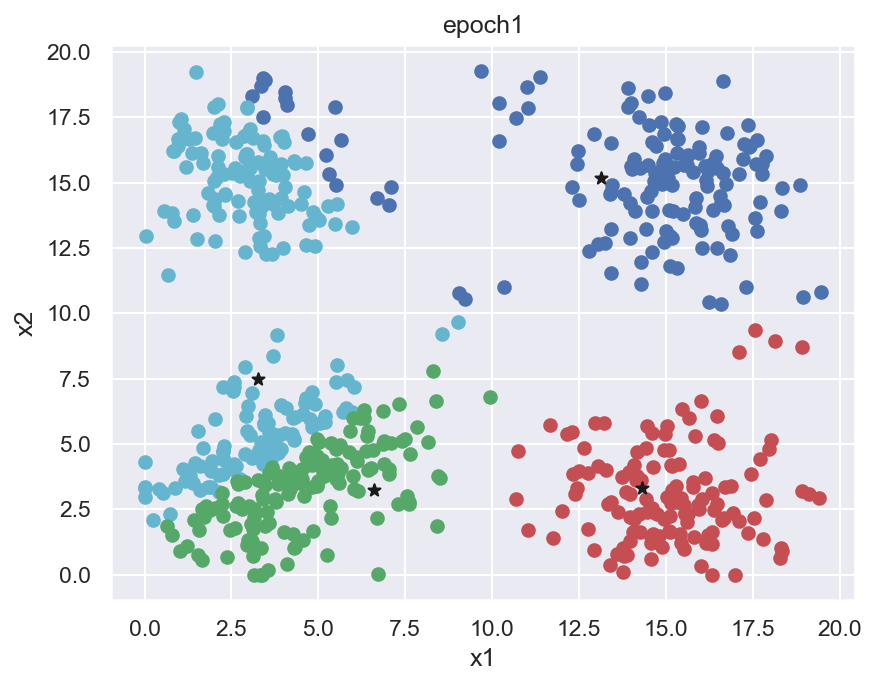

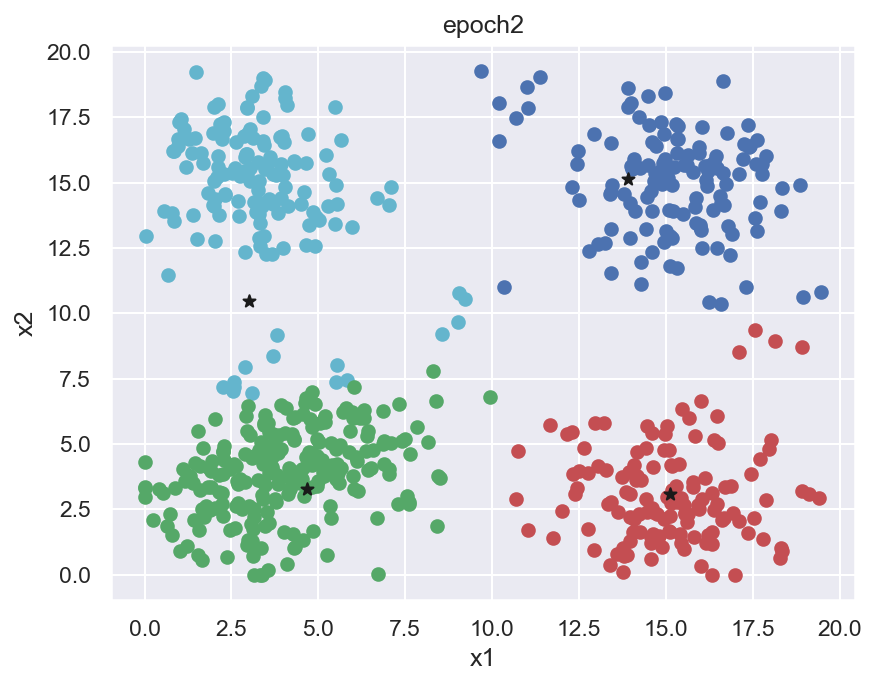

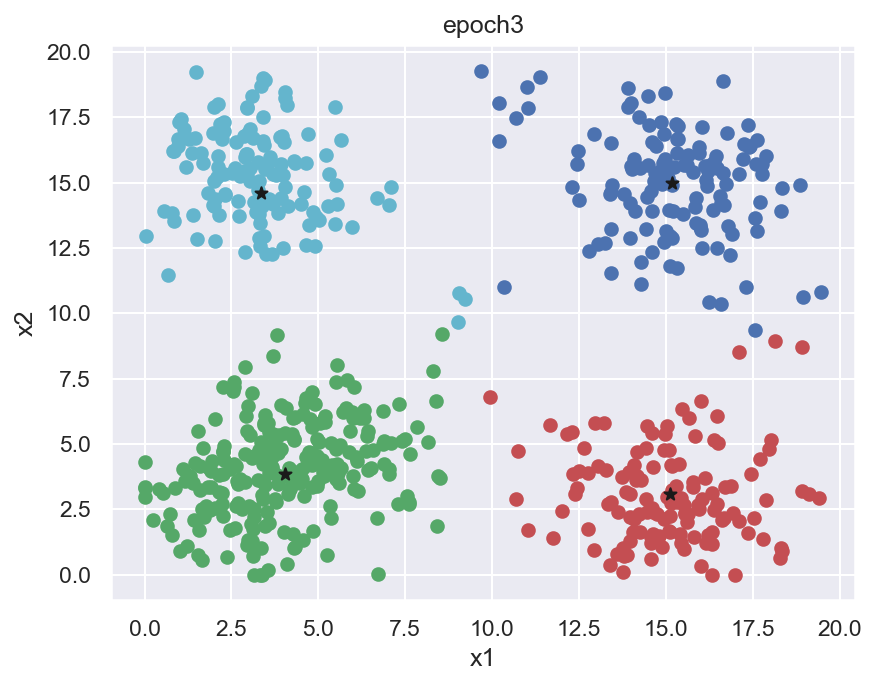

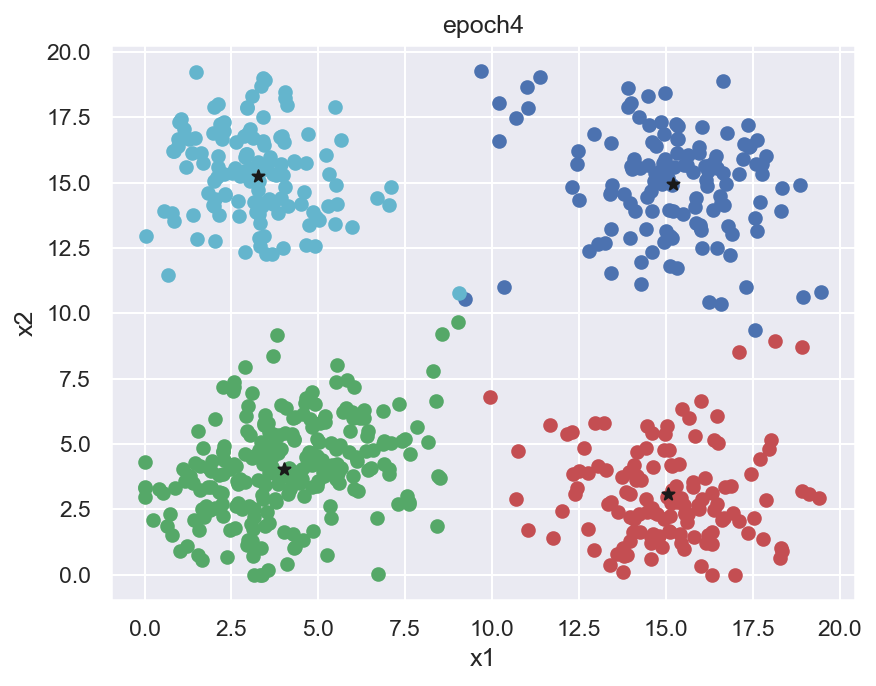

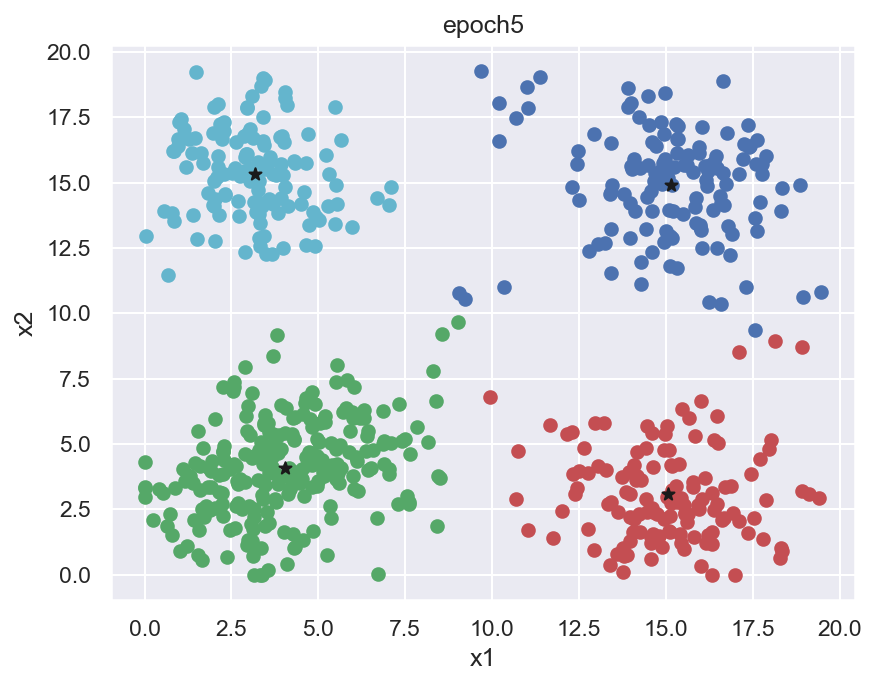

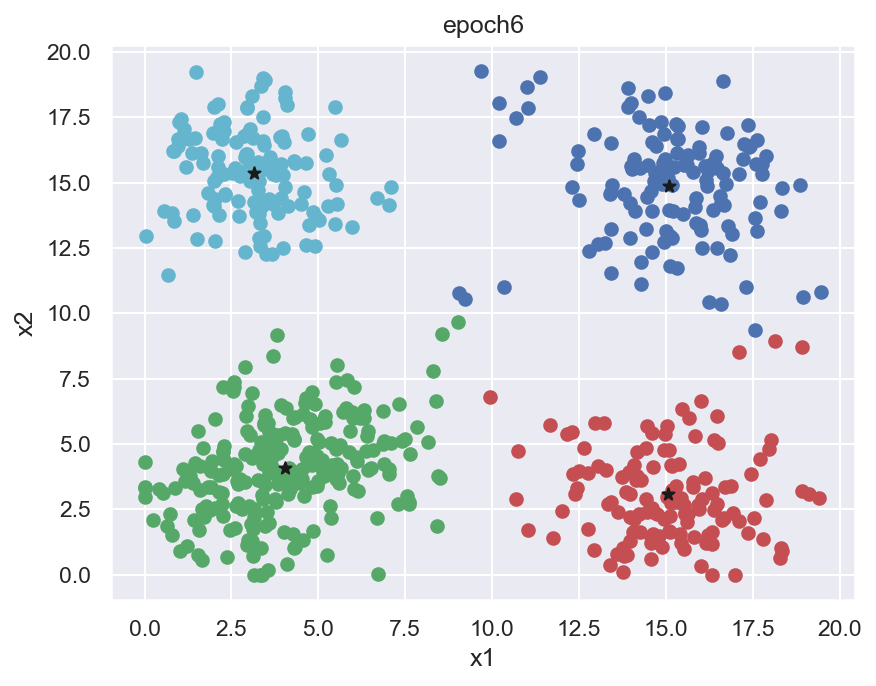

In [19]:
assignment, _ = kmeans(X, k, max_epoch)

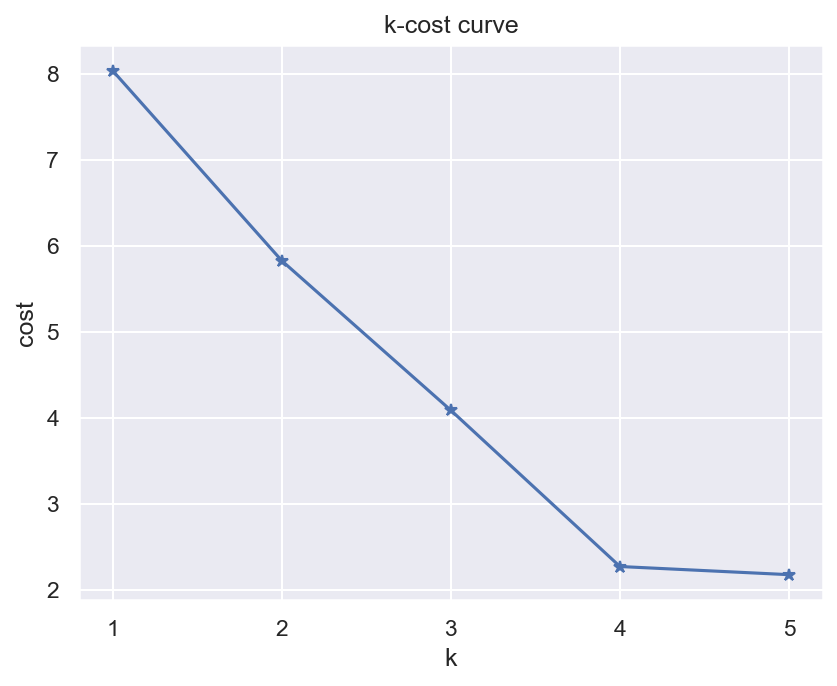

In [20]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch, False)
    Cost.append(cost)

plt.plot(range(1, max_k), Cost, c='b', marker='*')
plt.xticks(range(1, max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()